In [62]:
## Parte 1 -------------------------------------------------
# 0) Librerías
import io, re
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
#from google.colab import files


In [63]:
raw = pd.read_excel('tasa_participacion_mujeres.xls', header=None)

In [64]:

# 3) Detectar fila de inicio
date_mask = raw[0].astype(str).str.match(r"^\d{4}/\d{2}$", na=False)
if not date_mask.any():
    #Si la fecha viene como datetime ya; intentamos detectar filas convertibles a periodo
    tmp = pd.to_datetime(raw[0], errors="coerce", format="%Y/%m")
    date_mask = tmp.notna()

if not date_mask.any():
    # Sino, buscar AAAA-MM
    date_mask = raw[0].astype(str).str.match(r"^\d{4}[-]\d{2}$", na=False)

assert date_mask.any(), "No se encontró una fila con fechas tipo '2005/01' o '2005-01' en la primera columna."
start_row = int(date_mask[date_mask].index[0])

# 4) Construir DataFrame limpio (Periodos en col 0 y Valor en col 1)
df = raw.loc[start_row:, [0, 1]].copy()
df.columns = ["Fecha", "Tasa_participacion"]

# 5) Tipos correctos
df["Fecha"] = pd.to_datetime(df["Fecha"].astype(str), format="%Y/%m", errors="coerce")
if df["Fecha"].isna().all():
    df["Fecha"] = pd.to_datetime(df["Fecha"].astype(str), format="%Y-%m", errors="coerce")

df["Tasa_participacion"] = pd.to_numeric(df["Tasa_participacion"], errors="coerce")

In [65]:
df

,Fecha,Tasa_participacion
4,2005-01-01,40.351692
5,2005-02-01,40.432370
6,2005-03-01,41.179709
7,2005-04-01,39.732705
8,2005-05-01,41.027773
...,...,...
253,NaT,NaN
254,NaT,NaN
255,NaT,NaN
256,NaT,NaN


In [66]:

# 6) Limpiar y ordenar
df = (df
      .dropna(subset=["Fecha", "Tasa_participacion"])
      .set_index("Fecha")
      .sort_index())


Periodo detectado: 2005-01 a 2025-09

Resumen estadístico:
count    249.000000
mean      43.472531
std        1.748154
min       34.616667
25%       42.457499
50%       43.366709
75%       44.539689
max       47.135221

Archivo limpio guardado como: tasa_participacion_mujeres_clean.csv


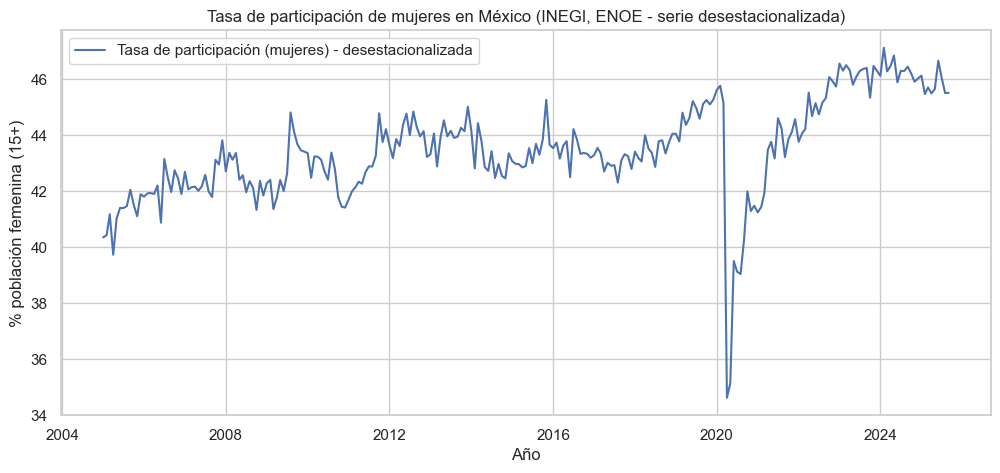

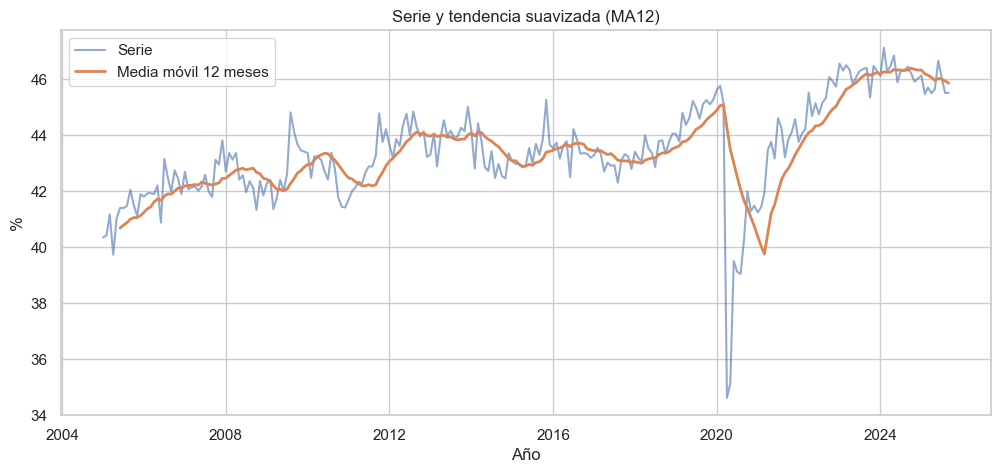

In [67]:


# 7) Reporteen consola
ini, fin = df.index.min(), df.index.max()
print(f"Periodo detectado: {ini.strftime('%Y-%m')} a {fin.strftime('%Y-%m')}")
print("\nResumen estadístico:")
print(df["Tasa_participacion"].describe().to_string())

# 8) Guardar versión limpia
clean_name = "tasa_participacion_mujeres_clean.csv"
df.to_csv(clean_name, encoding="utf-8")
print(f"\nArchivo limpio guardado como: {clean_name}")

# 9) Gráficas
plt.figure(figsize=(12,5))
plt.plot(df["Tasa_participacion"], label="Tasa de participación (mujeres) - desestacionalizada")
plt.title("Tasa de participación de mujeres en México (INEGI, ENOE - serie desestacionalizada)")
plt.xlabel("Año")
plt.ylabel("% población femenina (15+)")
plt.grid(True)
plt.legend()
plt.show()

# 10) Tendencia suavizada con media móvil de 12 meses
df["MA12"] = df["Tasa_participacion"].rolling(window=12, min_periods=6).mean()
plt.figure(figsize=(12,5))
plt.plot(df["Tasa_participacion"], label="Serie", alpha=0.6)
plt.plot(df["MA12"], label="Media móvil 12 meses", linewidth=2)
plt.title("Serie y tendencia suavizada (MA12)")
plt.xlabel("Año")
plt.ylabel("%")
plt.grid(True)
plt.legend()
plt.show()

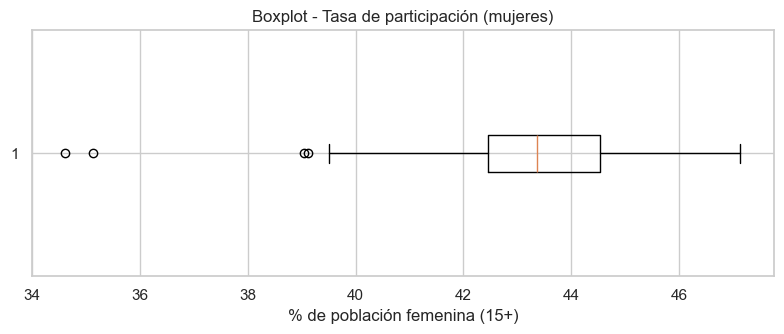

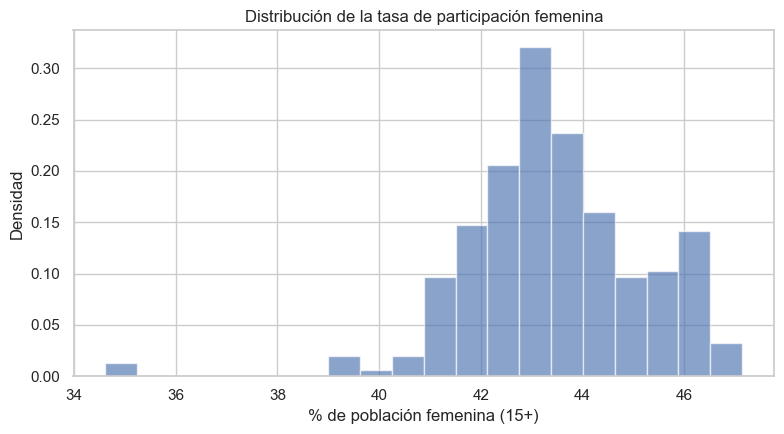

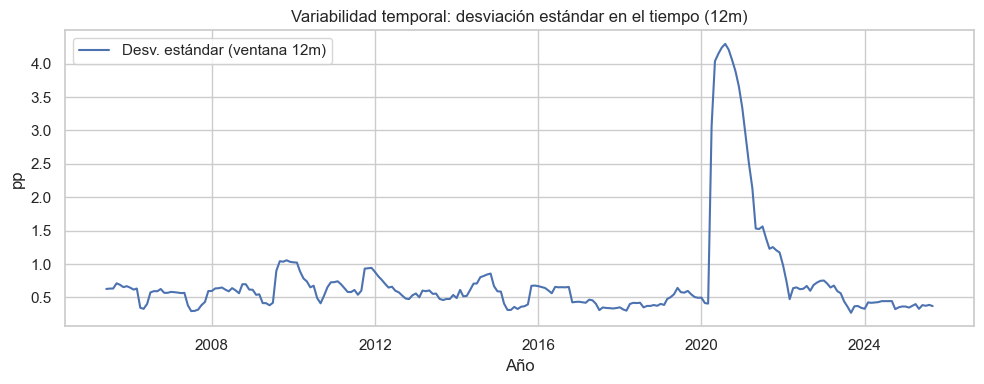

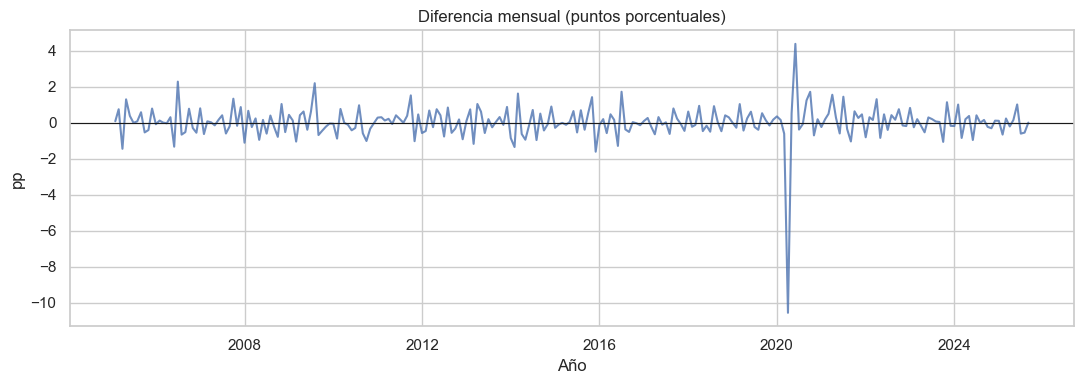

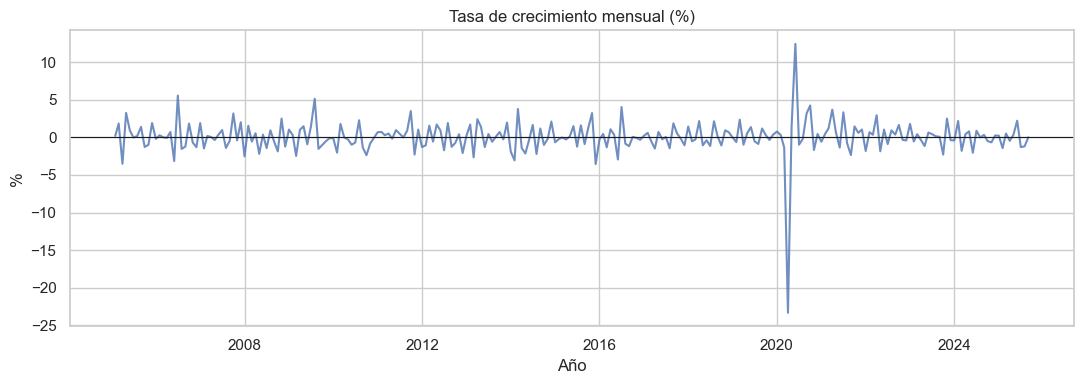

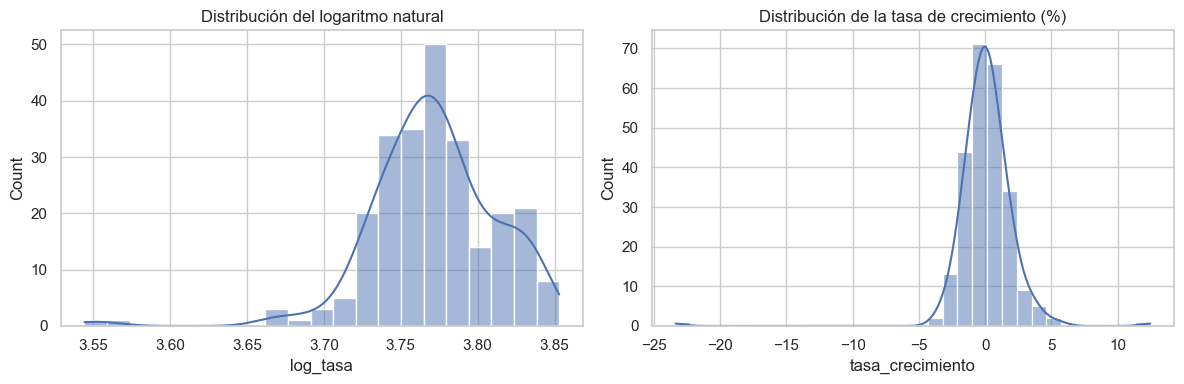


(Sección 2) Estadísticos y exploración

Periodo analizado: 2005-01 – 2025-09  |  Observaciones: 249
Media: 43.47 %, Desv.Est.: 1.75 pp, Min: 34.62 %, Mediana: 43.37 %, Max: 47.14 %
Asimetría (skew): -0.819   |   Curtosis (Fisher): 3.619
Posibles outliers (IQR): 4 observación(es) (ver meses listados abajo).


Meses marcado(s) como posible(s) outlier por IQR:
Fecha
2020-04-01    34.616667
2020-05-01    35.132391
2020-07-01    39.125171
2020-08-01    39.044937


In [68]:
# ===========================
# PARTE 2: Exploración y Transformaciones

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

# --- 0) Carpeta de salida para figuras
outdir = Path("figs")
outdir.mkdir(exist_ok=True)

# --- 1) Estadísticos descriptivos y forma de la distribución
serie = df['Tasa_participacion'].dropna().copy()
count = serie.shape[0]
mean  = serie.mean()
std   = serie.std()
q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
vmin, vmax = serie.min(), serie.max()

# Asimetría y curtosis (Fisher: normal=0)
try:
    from scipy.stats import skew, kurtosis
    skewness = float(skew(serie, nan_policy='omit'))
    kurt_f   = float(kurtosis(serie, nan_policy='omit'))  # Fisher
except Exception:
    skewness = float(serie.skew())       # Pearson
    kurt_f   = float(serie.kurt() - 3)   # aproximación a Fisher

# Detección de posibles outliers por IQR
iqr = q3 - q1
low_fence  = q1 - 1.5 * iqr
high_fence = q3 + 1.5 * iqr
outliers = serie[(serie < low_fence) | (serie > high_fence)]
n_out = outliers.shape[0]

# --- 2) Visualizaciones de la serie
# 2.1 Boxplot
plt.figure(figsize=(8,3.5))
plt.boxplot(serie.values, vert=False, whis=1.5)
plt.title('Boxplot - Tasa de participación (mujeres)')
plt.xlabel('% de población femenina (15+)')
plt.tight_layout()
plt.savefig(outdir / "fig03_boxplot.png", dpi=180)
plt.show()

# 2.2 Histograma (con densidad)
plt.figure(figsize=(8,4.5))
plt.hist(serie.values, bins=20, density=True, alpha=0.65)
plt.title('Distribución de la tasa de participación femenina')
plt.xlabel('% de población femenina (15+)')
plt.ylabel('Densidad')
plt.tight_layout()
plt.savefig(outdir / "fig04_histograma.png", dpi=180)
plt.show()

# 2.3 Desviación estándar en el tiempo
roll_w = 12
roll_std = serie.rolling(roll_w, min_periods=6).std()

plt.figure(figsize=(10,4))
plt.plot(roll_std, label=f'Desv. estándar (ventana {roll_w}m)')
plt.title('Variabilidad temporal: desviación estándar en el tiempo (12m)')
plt.xlabel('Año'); plt.ylabel('pp')
plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig(outdir / "fig04b_rolling_std.png", dpi=180)
plt.show()

# --- 3) Transformaciones
# 3.1 Logaritmo (no imprescindible en porcentajes)
df['log_tasa'] = np.log(df['Tasa_participacion'])

# 3.2 Diferencia en puntos porcentuales (cambio absoluto mensual)
df['diff_pp'] = df['Tasa_participacion'].diff(1)

# 3.3 Tasa de crecimiento mensual (%) (cambio relativo)
df['crec_%']  = df['Tasa_participacion'].pct_change(1) * 100
df['tasa_crecimiento'] = df['crec_%']  # alias para gráficos

# 3.4 Visualización de transformaciones (series en el tiempo)
plt.figure(figsize=(11,4))
plt.plot(df['diff_pp'], alpha=0.8)
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Diferencia mensual (puntos porcentuales)')
plt.xlabel('Año'); plt.ylabel('pp')
plt.grid(True)
plt.tight_layout()
plt.savefig(outdir / "fig05a_diff_pp.png", dpi=180)
plt.show()

plt.figure(figsize=(11,4))
plt.plot(df['crec_%'], alpha=0.8)
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Tasa de crecimiento mensual (%)')
plt.xlabel('Año'); plt.ylabel('%')
plt.grid(True)
plt.tight_layout()
plt.savefig(outdir / "fig05b_crec_pct.png", dpi=180)
plt.show()

# 3.5 Visualización de transformaciones (distribuciones)
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['log_tasa'].dropna(), kde=True, ax=ax[0])
ax[0].set_title('Distribución del logaritmo natural')
sns.histplot(df['tasa_crecimiento'].dropna(), kde=True, ax=ax[1])
ax[1].set_title('Distribución de la tasa de crecimiento (%)')
plt.tight_layout()
plt.savefig(outdir / "fig05c_log_hist.png", dpi=180)
plt.savefig(outdir / "fig05d_growth_hist.png", dpi=180)
plt.show()

# --- 4) Resumen para pegar en Word (autollenado)
ini, fin = serie.index.min(), serie.index.max()
txt = f"""
(Sección 2) Estadísticos y exploración

Periodo analizado: {ini.strftime('%Y-%m')} – {fin.strftime('%Y-%m')}  |  Observaciones: {count}
Media: {mean:.2f} %, Desv.Est.: {std:.2f} pp, Min: {vmin:.2f} %, Mediana: {q2:.2f} %, Max: {vmax:.2f} %
Asimetría (skew): {skewness:.3f}   |   Curtosis (Fisher): {kurt_f:.3f}
Posibles outliers (IQR): {n_out} observación(es){' (ver meses listados abajo)' if n_out>0 else ''}.

"""
print(txt)

if n_out > 0:
    print("Meses marcado(s) como posible(s) outlier por IQR:")
    print(outliers.sort_index().to_string())


Prueba Dickey-Fuller Aumentada (ADF) - Serie en niveles
ADF Statistic: -3.132231476947229
p-value: 0.024258055850297087
# Lags Used: 2
# Observations: 246
Critical Value 1%: -3.457215237265747
Critical Value 5%: -2.873361841566324
Critical Value 10%: -2.5730700760129555

Conclusión:  Rechazar H0 (serie estacionaria)


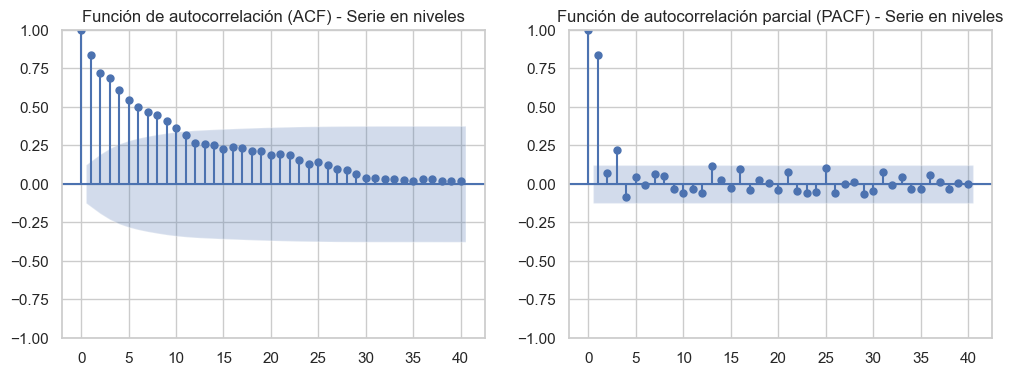


Prueba Dickey-Fuller Aumentada (ADF) - Primera diferencia
ADF Statistic: -15.902705355748825
p-value: 8.293961936443131e-29
# Lags Used: 1
# Observations: 246
Critical Value 1%: -3.457215237265747
Critical Value 5%: -2.873361841566324
Critical Value 10%: -2.5730700760129555

Conclusión:  Rechazar H0 (serie estacionaria)


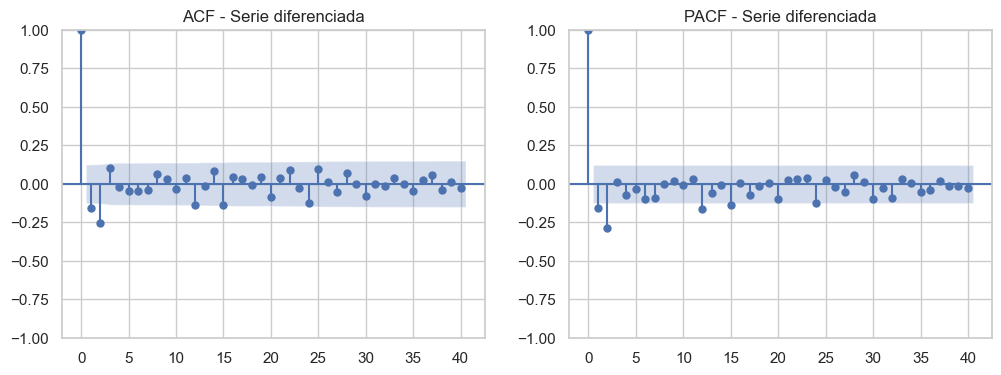

In [69]:
# ===========================
# PARTE 3: Verificación de estacionariedad

from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1) Prueba ADF en la serie original
print("Prueba Dickey-Fuller Aumentada (ADF) - Serie en niveles")
result = adfuller(df['Tasa_participacion'].dropna(), autolag='AIC')
labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations']
for val, label in zip(result[:4], labels):
    print(f"{label}: {val}")
for key, val in result[4].items():
    print(f"Critical Value {key}: {val}")
print("\nConclusión: ", "Rechazar H0 (serie estacionaria)" if result[1]<0.05 else "No rechazar H0 (serie no estacionaria)")

#  2) ACF y PACF de la serie original
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(df['Tasa_participacion'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['Tasa_participacion'].dropna(), lags=40, ax=axes[1])
axes[0].set_title('Función de autocorrelación (ACF) - Serie en niveles')
axes[1].set_title('Función de autocorrelación parcial (PACF) - Serie en niveles')
plt.show()

# 3) Prueba ADF sobre la serie diferenciada
df['diff_1'] = df['Tasa_participacion'].diff()
print("\nPrueba Dickey-Fuller Aumentada (ADF) - Primera diferencia")
result_diff = adfuller(df['diff_1'].dropna(), autolag='AIC')
for val, label in zip(result_diff[:4], labels):
    print(f"{label}: {val}")
for key, val in result_diff[4].items():
    print(f"Critical Value {key}: {val}")
print("\nConclusión: ", "Rechazar H0 (serie estacionaria)" if result_diff[1]<0.05 else "No rechazar H0 (serie no estacionaria)")

#  4) ACF y PACF de la serie diferenciada
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(df['diff_1'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['diff_1'].dropna(), lags=40, ax=axes[1])
axes[0].set_title('ACF - Serie diferenciada')
axes[1].set_title('PACF - Serie diferenciada')
plt.show()


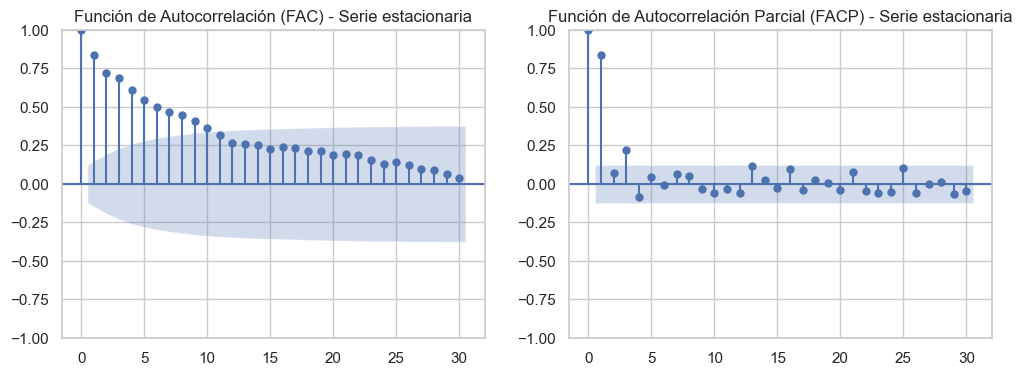

Primeros coeficientes de la FAC:
Lag 0: 1.000
Lag 1: 0.836
Lag 2: 0.720
Lag 3: 0.684
Lag 4: 0.608
Lag 5: 0.546
Lag 6: 0.500
Lag 7: 0.468
Lag 8: 0.449
Lag 9: 0.411
Lag 10: 0.360

Primeros coeficientes de la FACP:
Lag 0: 1.000
Lag 1: 0.839
Lag 2: 0.072
Lag 3: 0.227
Lag 4: -0.086
Lag 5: 0.045
Lag 6: -0.011
Lag 7: 0.070
Lag 8: 0.052
Lag 9: -0.033
Lag 10: -0.062


In [70]:
# ===========================
# PARTE 4: Diagnóstico con FAC y FACP

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Serie estacionaria (original)
serie = df['Tasa_participacion'].dropna()

# 1) Calcular y graficar FAC y FACP
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(serie, lags=30, ax=axes[0])
plot_pacf(serie, lags=30, ax=axes[1])
axes[0].set_title('Función de Autocorrelación (FAC) - Serie estacionaria')
axes[1].set_title('Función de Autocorrelación Parcial (FACP) - Serie estacionaria')
plt.show()

# 2) Inspeccionar los primeros coeficientes numéricamente
from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(serie, nlags=10)
pacf_vals = pacf(serie, nlags=10)

print("Primeros coeficientes de la FAC:")
for i, v in enumerate(acf_vals):
    print(f"Lag {i}: {v:.3f}")

print("\nPrimeros coeficientes de la FACP:")
for i, v in enumerate(pacf_vals):
    print(f"Lag {i}: {v:.3f}")


In [71]:
# ===========================
# PARTE 5: Estimación del modelo 


import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1) Definir la serie estacionaria (ya usada antes)
serie = df['Tasa_participacion'].dropna()


In [72]:

#  Ajustar el modelo AR(1) ~ ARIMA(1,0,0)
model_ar1 = ARIMA(serie, order=(1, 0, 0)).fit()

print("=== Modelo AR(1) estimado sobre la serie en niveles ===")
print(model_ar1.summary())

#  Extraer parámetros clave
phi1 = model_ar1.params.get('ar.L1', float('nan'))
const = model_ar1.params.get('const', float('nan'))

print("\nParámetros principales:")
print(f"Constante: {const:.4f}")
print(f"Phi_1 (AR1): {phi1:.4f}")
print(f"AIC: {model_ar1.aic:.2f}")
print(f"BIC: {model_ar1.bic:.2f}")


=== Modelo AR(1) estimado sobre la serie en niveles ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -337.648
Date:                Sat, 15 Nov 2025   AIC                            681.296
Time:                        17:51:49   BIC                            691.848
Sample:                    01-01-2005   HQIC                           685.543
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4494      0.506     85.895      0.000      42.458      44.441
ar.L1          0.8480      0.031     27.307      0.000       0.787       0.

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [73]:

#  Residuos del modelo
resid = model_ar1.resid

#  Prueba de Ljung–Box para los residuos
lb = acorr_ljungbox(resid, lags=[10], return_df=True)

print("\n=== Prueba de Ljung–Box (residuos AR(1)) ===")
print(lb)

pval = lb['lb_pvalue'].iloc[0]
if pval > 0.05:
    print("\nConclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).")
else:
    print("\nConclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo AR(1) puede ser insuficiente).")



=== Prueba de Ljung–Box (residuos AR(1)) ===
      lb_stat  lb_pvalue
10  19.270314   0.036961

Conclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo AR(1) puede ser insuficiente).


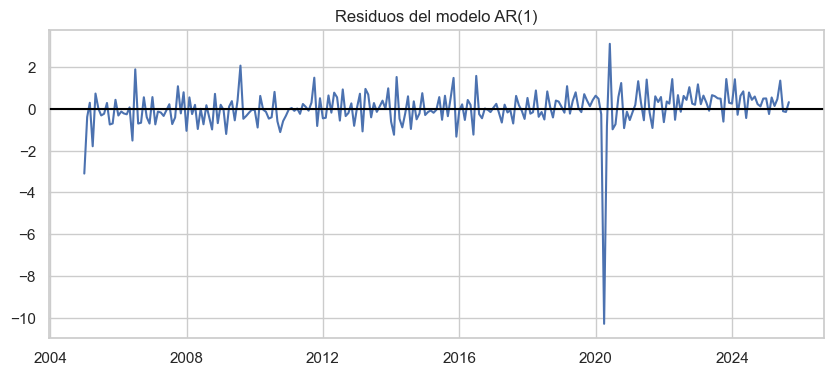

In [74]:
plt.figure(figsize=(10,4))
plt.plot(serie.index, resid)
plt.axhline(0, color='black')
plt.title("Residuos del modelo AR(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

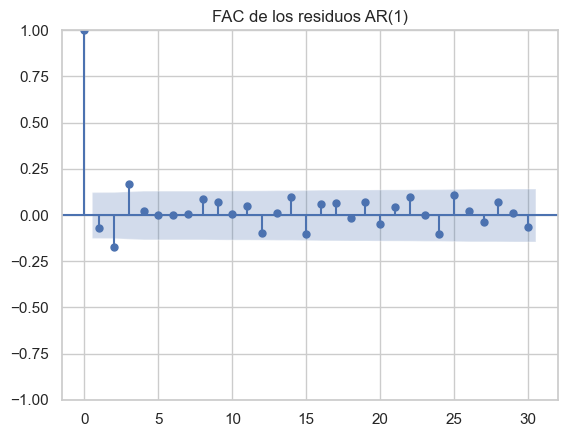

In [75]:
plt.figure(figsize=(8,4))
plot_acf(resid, lags=30)
plt.title("FAC de los residuos AR(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

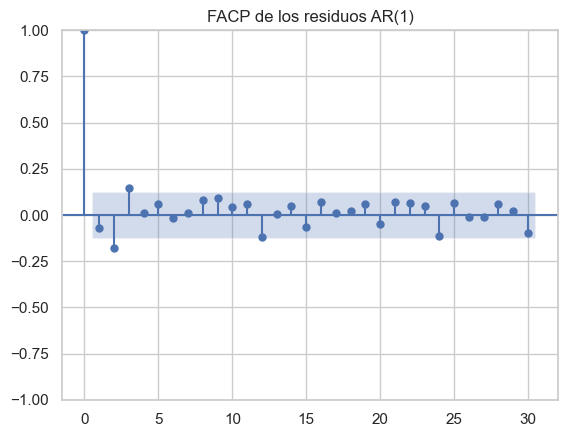

In [76]:

plt.figure(figsize=(8,4))
plot_pacf(resid, lags=30)
plt.title("FACP de los residuos AR(1)")
plt.show()

In [87]:
#  MA(1)

model_ma1 = ARIMA(serie, order=(0, 0, 1)).fit()

print("=== Modelo MA(1) estimado sobre la serie en niveles ===")
print(model_ma1.summary())

#  Extraer parámetros clave
theta1 = model_ma1.params.get('ma.L1', float('nan'))
const = model_ma1.params.get('const', float('nan'))

print("\nParámetros principales:")
print(f"Constante: {const:.4f}")
print(f"Theta_1 (MA1): {theta1:.4f}")
print(f"AIC: {model_ma1.aic:.2f}")
print(f"BIC: {model_ma1.bic:.2f}")


=== Modelo MA(1) estimado sobre la serie en niveles ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -399.829
Date:                Sat, 15 Nov 2025   AIC                            805.658
Time:                        18:13:53   BIC                            816.211
Sample:                    01-01-2005   HQIC                           809.906
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4728      0.151    288.085      0.000      43.177      43.769
ma.L1          0.7455      0.039     19.339      0.000       0.670       0.

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [88]:

# 4) Residuos del modelo
resid = model_ma1.resid

# 4.3) Prueba de Ljung–Box para los residuos
lb = acorr_ljungbox(resid, lags=[10], return_df=True)

print("\n=== Prueba de Ljung–Box (residuos MA(1)) ===")
print(lb)

pval = lb['lb_pvalue'].iloc[0]
if pval > 0.05:
    print("\nConclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).")
else:
    print("\nConclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo MA(1) puede ser insuficiente).")



=== Prueba de Ljung–Box (residuos MA(1)) ===
       lb_stat     lb_pvalue
10  373.149588  4.832342e-74

Conclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo MA(1) puede ser insuficiente).


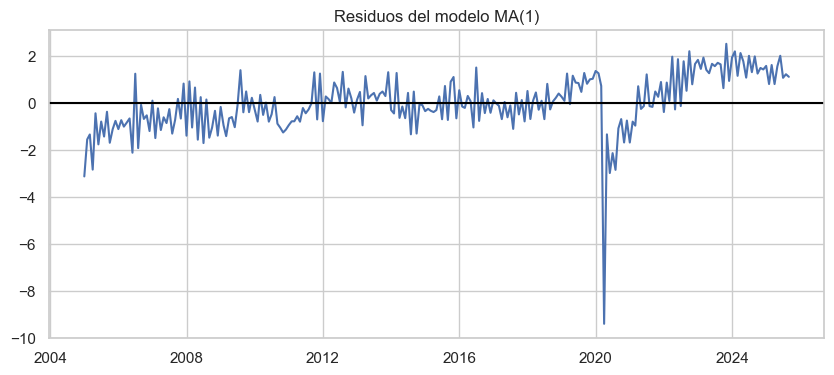

In [89]:
plt.figure(figsize=(10,4))
plt.plot(serie.index, resid)
plt.axhline(0, color='black')
plt.title("Residuos del modelo MA(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

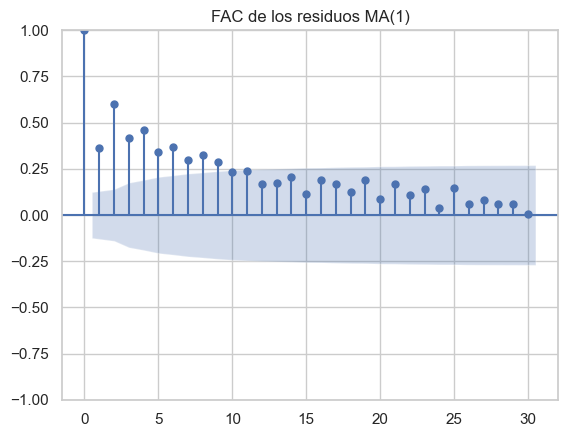

In [90]:
plt.figure(figsize=(8,4))
plot_acf(resid, lags=30)
plt.title("FAC de los residuos MA(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

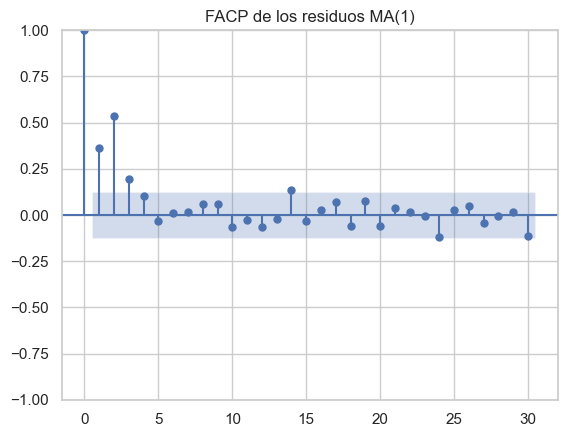

In [91]:
plt.figure(figsize=(8,4))
plot_pacf(resid, lags=30)
plt.title("FACP de los residuos MA(1)")
plt.show()


In [92]:
# ARMA(1,1)

model_arma11 = ARIMA(serie, order=(1, 0, 1)).fit()

print("=== Modelo ARMA(1,1) estimado sobre la serie en niveles ===")
print(model_arma11.summary())

# 3) Extraer parámetros clave
phi1   = model_arma11.params.get('ar.L1', float('nan'))
theta1 = model_arma11.params.get('ma.L1', float('nan'))
const  = model_arma11.params.get('const', float('nan'))

print("\nParámetros principales:")
print(f"Constante: {const:.4f}")
print(f"Phi_1 (AR1): {phi1:.4f}")
print(f"Theta_1 (MA1): {theta1:.4f}")
print(f"AIC: {model_arma11.aic:.2f}")
print(f"BIC: {model_arma11.bic:.2f}")


=== Modelo ARMA(1,1) estimado sobre la serie en niveles ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -335.943
Date:                Sat, 15 Nov 2025   AIC                            679.885
Time:                        18:50:46   BIC                            693.955
Sample:                    01-01-2005   HQIC                           685.549
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4391      0.620     70.053      0.000      42.224      44.654
ar.L1          0.8998      0.039     23.089      0.000       0.823     

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [83]:

# 4) Residuos del modelo
resid = model_arma11.resid

# 4.3) Prueba de Ljung–Box para los residuos
lb = acorr_ljungbox(resid, lags=[10], return_df=True)

print("\n=== Prueba de Ljung–Box (residuos ARMA(1,1)) ===")
print(lb)

pval = lb['lb_pvalue'].iloc[0]
if pval > 0.05:
    print("\nConclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).")
else:
    print("\nConclusión: Se rechaza H0; los residuos muestran autocorrelación.")



=== Prueba de Ljung–Box (residuos ARMA(1,1)) ===
      lb_stat  lb_pvalue
10  15.931045   0.101623

Conclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).


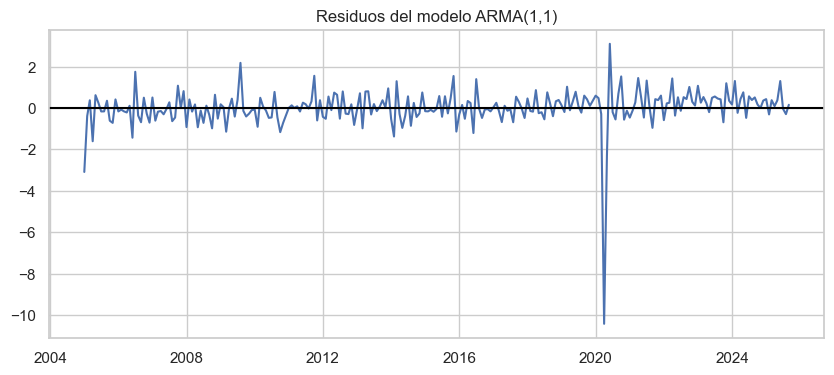

In [84]:
plt.figure(figsize=(10,4))
plt.plot(serie.index, resid)
plt.axhline(0, color='black')
plt.title("Residuos del modelo ARMA(1,1)")
plt.show()


<Figure size 800x400 with 0 Axes>

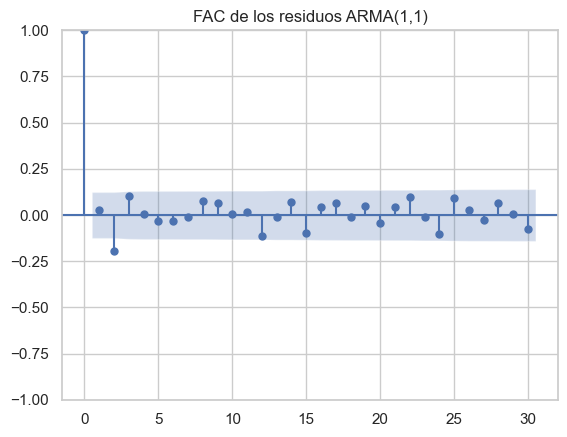

In [85]:
plt.figure(figsize=(8,4))
plot_acf(resid, lags=30)
plt.title("FAC de los residuos ARMA(1,1)")
plt.show()


<Figure size 800x400 with 0 Axes>

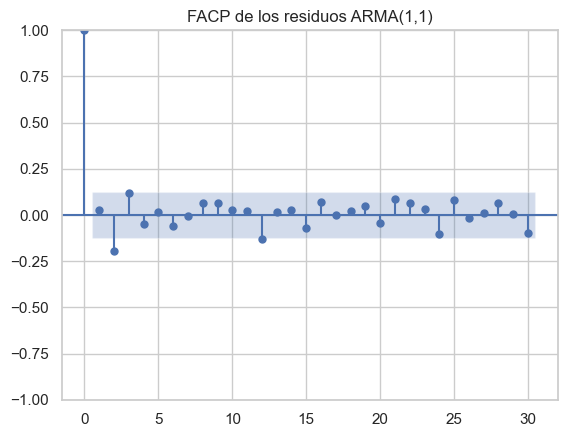

In [86]:
plt.figure(figsize=(8,4))
plot_pacf(resid, lags=30)
plt.title("FACP de los residuos ARMA(1,1)")
plt.show()


In [93]:
import pandas as pd

modelos = {
    "AR(1)": model_ar1,
    "MA(1)": model_ma1,
    "ARMA(1,1)": model_arma11,
}

rows_ic = []
for nombre, mod in modelos.items():
    rows_ic.append({
        "Modelo": nombre,
        "AIC": mod.aic,
        "BIC": mod.bic,
    })

df_ic = pd.DataFrame(rows_ic)
df_ic


,Modelo,AIC,BIC
0,AR(1),681.295796,691.848155
1,MA(1),805.658408,816.210766
2,"ARMA(1,1)",679.885451,693.955262


In [94]:
rows_sig = []

for nombre, mod in modelos.items():
    params = mod.params
    pvals = mod.pvalues

    for par in params.index:
        # si no quieres sigma2 en la tabla, lo filtramos
        if par.lower().startswith("sigma"):
            continue
        
        rows_sig.append({
            "Modelo": nombre,
            "Parametro": par,
            "Estimacion": params[par],
            "p_value": pvals[par],
            "Significativo_5pct": pvals[par] < 0.05
        })

df_sig = pd.DataFrame(rows_sig)
df_sig


,Modelo,Parametro,Estimacion,p_value,Significativo_5pct
0,AR(1),const,43.449419,0.000000e+00,True
1,AR(1),ar.L1,0.848004,3.495771e-164,True
2,MA(1),const,43.472801,0.000000e+00,True
3,MA(1),ma.L1,0.745530,2.542017e-83,True
4,"ARMA(1,1)",const,43.439123,0.000000e+00,True
5,"ARMA(1,1)",ar.L1,0.899776,5.984190e-118,True
6,"ARMA(1,1)",ma.L1,-0.187464,3.701498e-04,True
